# 2-Beads CNEEP_v2 — Using CNEEP pre-generated data

CNEEP의 `data/beads_2/` 디렉토리에 있는 사전 생성 데이터를 로드하여
CNEEP_v2의 U-Net 모델로 학습하는 노트북입니다.

- Train images: `(100, 10000, 1, 20, 40)` — 100 trajectories × 10000 steps
- Train trajectories: `(100, 10000, 2)` — 2-bead positions
- Test images/trajectories: same shape

In [ ]:
import sys, os

# --- Google Colab ---
# from google.colab import drive
# drive.mount('/content/drive')
# CNEEP_ROOT   = 'drive/MyDrive/CNEEP'
# CNEEP_V2_ROOT = 'drive/MyDrive/CNEEP_v2'
from google.colab import drive
drive.mount('/content/drive')
# --- Local ---
CNEEP_ROOT    = 'drive/MyDrive/CNEEP/'
CNEEP_V2_ROOT = 'drive/MyDrive/CNEEP_v2/'

sys.path.append(CNEEP_ROOT)
sys.path.append(CNEEP_V2_ROOT)
sys.path.append(os.path.join(CNEEP_V2_ROOT, 'data', 'beads'))

from argparse import Namespace
import numpy as np
import torch
from datetime import datetime
from utils.sampler import CartesianSeqSampler
from models.train import train
from models.validate import validate
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

from toy.bead_spring import del_medium_etpy, del_shannon_etpy

Mounted at /content/drive


In [17]:
#
# Hyper parameters
#
opt = Namespace()
opt.device = "cuda" if torch.cuda.is_available() else "cpu"

opt.N = 2

# alpha-NEEP parameter
opt.alpha   = -0.5
# Masking Regularization parameters
opt.lam     = 0.0
opt.threshold = 0.01

opt.positional = False
opt.latent_size = 10

# gradient descent parameters
opt.n_iter = 200
opt.train_batch_size = 4096
opt.test_batch_size = 4096
opt.video_batch_size = 512
opt.n_hidden = 512
opt.lr = 1e-3
opt.wd = 1e-5

opt.record_freq = 1000
opt.seed = 3

# dataset configurations
opt.n_layer = 2
opt.n_channel = 32
opt.input_shape = (20, 40)
opt.M = 10        # CNEEP data has 100 trajectories
opt.L = 1000      # CNEEP data has 10000 steps each
opt.seq_len = 2
opt.Tc = 1
opt.Th = 10
opt.time_step = 0.01

torch.manual_seed(opt.seed)

#
# path for results
#
result_folder = os.path.join(CNEEP_V2_ROOT, 'results')
current_result_folder = os.path.join(
    result_folder, f"Beads-CNEEP-{datetime.now().strftime('%Y-%m-%d-%H%M%S')}")
os.makedirs(current_result_folder, exist_ok=True)

current_checkpoint_path = os.path.join(current_result_folder, 'model_parameter.pth.tar')

print(f"Device: {opt.device}")
print(f"Results: {current_result_folder}")

Device: cuda
Results: drive/MyDrive/CNEEP_v2/results/Beads-CNEEP-2026-02-23-130350


## Load CNEEP pre-generated data

In [5]:
#
# Loading pre-generated data from CNEEP repo
#
data_dir = os.path.join(CNEEP_ROOT, 'data', 'beads_2')

# --- Train ---
train_imgs = np.load(os.path.join(
    data_dir, 'train', f'img_2beads_1.0_({opt.Tc}, {opt.Th}).npy'))[:opt.M, :opt.L]
train_trajs_np = np.load(os.path.join(
    data_dir, 'train', f'trj_2beads_0_({opt.Tc}, {opt.Th}).npy'))[:opt.M, :opt.L]

train_video = torch.from_numpy(train_imgs).float().reshape(
    opt.M, opt.L, 1, 20, 40)
train_trajs = torch.from_numpy(train_trajs_np).float()

# --- Test ---
test_imgs = np.load(os.path.join(
    data_dir, 'test', f'img_2beads_1.0_({opt.Tc}, {opt.Th}).npy'))[:opt.M, :opt.L]
test_trajs_np = np.load(os.path.join(
    data_dir, 'test', f'trj_2beads_0_({opt.Tc}, {opt.Th}).npy'))[:opt.M, :opt.L]

test_video = torch.from_numpy(test_imgs).float().reshape(
    opt.M, opt.L, 1, 20, 40)
test_trajs = torch.from_numpy(test_trajs_np).float()

print(f'Train images:       {train_video.shape}')
print(f'Train trajectories: {train_trajs.shape}')
print(f'Test images:        {test_video.shape}')
print(f'Test trajectories:  {test_trajs.shape}')

Train images:       torch.Size([10, 1000, 1, 20, 40])
Train trajectories: torch.Size([10, 1000, 2])
Test images:        torch.Size([10, 1000, 1, 20, 40])
Test trajectories:  torch.Size([10, 1000, 2])


In [6]:
#
# Compute normalization stats from full training data
#
mean = torch.mean(train_video)
std  = torch.std(train_video)
transform = lambda x: (x - mean) / std

print(f'Global mean: {mean:.4f}')
print(f'Global std:  {std:.4f}')

Global mean: 35.5240
Global std:  57.4349


In [7]:
#
# Compute ground truth entropy production (using CNEEP's bead_spring module)
#
sys.path.insert(0, CNEEP_ROOT)

GT_ent_list = []
for i in range(opt.M):
    # del_medium_etpy expects (num_traj, trj_len, n_beads)
    trj_i = test_trajs[i].unsqueeze(0)  # (1, L, 2)
    dS_med = del_medium_etpy(trj_i, opt.Tc, opt.Th)
    GT_ent_list.append(dS_med.squeeze(0).numpy())

GT_ent = np.array(GT_ent_list)  # (M, L-1)
print(f'GT entropy shape: {GT_ent.shape}')
print(f'GT mean EP rate:  {GT_ent.mean() / opt.time_step:.6f}')

GT entropy shape: (10, 999)
GT mean EP rate:  2.090749


## Build and Train Model

In [18]:
#
# Building our model
#
from models.UNEEP_1P import CNEEP

model = CNEEP(opt)
model = model.to(opt.device)
optim = torch.optim.Adam(
    model.parameters(), opt.lr, weight_decay=opt.wd)
train_sampler = CartesianSeqSampler(
    opt.M, opt.L, opt.seq_len, opt.train_batch_size, device=opt.device
)
test_sampler = CartesianSeqSampler(
    opt.M, opt.L, opt.seq_len, opt.test_batch_size, device=opt.device,
    train=False
)

print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')

Model parameters: 57,889


In [19]:
#
# Training the model
#
train_losses = []
R_values = []
valid_losses = []
best_valid_loss = float('inf')

for i in tqdm(range(1, opt.n_iter + 1)):
    train_loss, R_value = train(
        opt, model, optim, train_video, train_sampler, transform
    )
    train_losses.append(train_loss)
    R_values.append(R_value)

    _, _, valid_loss = validate(
        opt, model, test_video, test_sampler, transform
    )
    valid_losses.append(valid_loss)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        state = {
            'epoch': i,
            'settings': opt.__dict__,
            'state_dict': model.state_dict(),
            'optimizer': optim.state_dict(),
        }
        torch.save(state, current_checkpoint_path)

model.load_state_dict(
    torch.load(current_checkpoint_path)['state_dict'])

100%|██████████| 200/200 [05:06<00:00,  1.53s/it]


<All keys matched successfully>

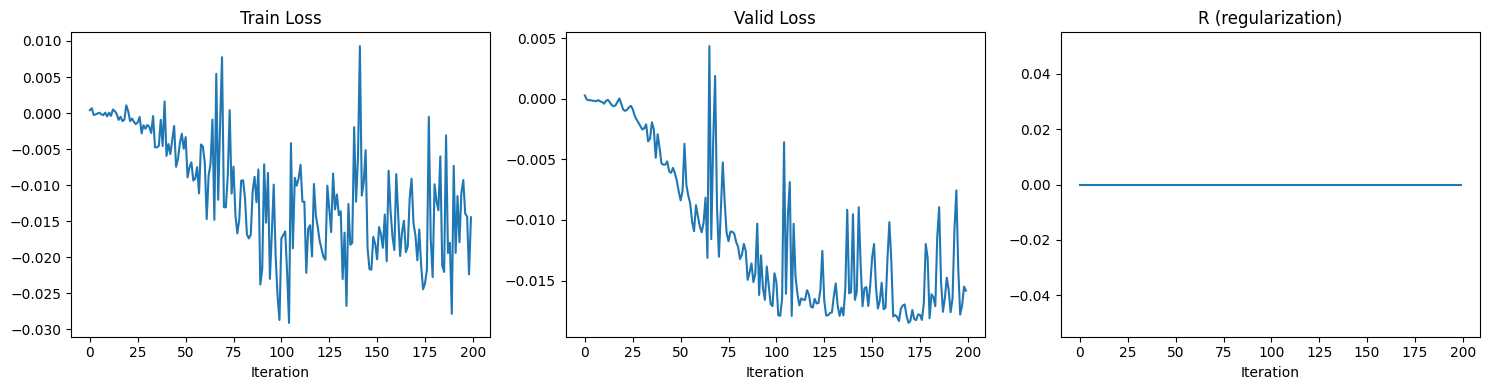

In [20]:
#
# Training curves
#
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(train_losses)
axes[0].set_title('Train Loss')
axes[0].set_xlabel('Iteration')

axes[1].plot(valid_losses)
axes[1].set_title('Valid Loss')
axes[1].set_xlabel('Iteration')

axes[2].plot(R_values)
axes[2].set_title('R (regularization)')
axes[2].set_xlabel('Iteration')

plt.tight_layout()
plt.savefig(f'{current_result_folder}/training_curves.png', dpi=150)
plt.show()

## Evaluation: R² scatter plot

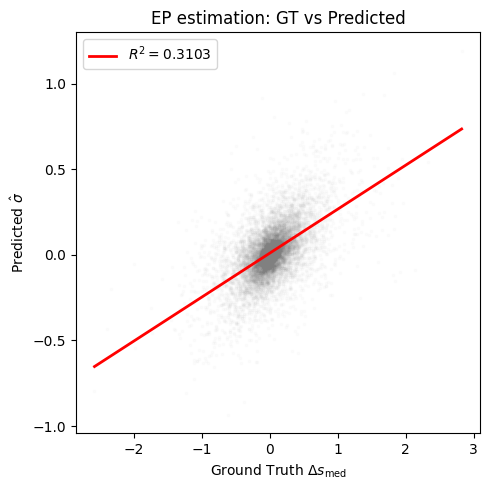

R²  = 0.310296
EP rate (predicted) = 1.581310


In [21]:
from scipy import stats

test_sampler = CartesianSeqSampler(
    opt.M, opt.L, opt.seq_len, opt.test_batch_size,
    device=opt.device, train=False
)
pred_ent, _, _ = validate(opt, model, test_video, test_sampler, transform)

pred = pred_ent.flatten()
ent  = GT_ent.flatten()

# Ensure same length (pred may have one fewer element per trajectory)
min_len = min(len(pred), len(ent))
pred = pred[:min_len]
ent  = ent[:min_len]

slope, intercept, r_value, p_value, _ = stats.linregress(ent, pred)

plt.figure(figsize=(5, 5), dpi=100)
plt.scatter(ent, pred, alpha=0.02, s=3, color='grey', rasterized=True)

# regression line
x_line = np.linspace(ent.min(), ent.max(), 100)
plt.plot(x_line, slope * x_line + intercept, 'r-', lw=2,
         label=f'$R^2 = {r_value**2:.4f}$')

plt.xlabel('Ground Truth $\\Delta s_{\\mathrm{med}}$')
plt.ylabel('Predicted $\\hat{\\sigma}$')
plt.legend()
plt.title('EP estimation: GT vs Predicted')
plt.tight_layout()
plt.savefig(f'{current_result_folder}/R2_plot.png', dpi=150)
plt.show()

print(f'R²  = {r_value**2:.6f}')
print(f'EP rate (predicted) = {pred.mean() / opt.time_step:.6f}')

## Entropy map visualization

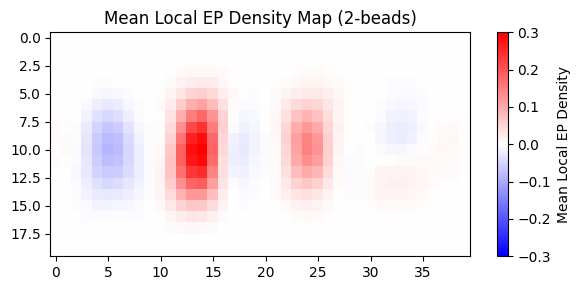

5.510621 3.6322856


In [37]:
#
# Entropy production map for a single trajectory
#
single_sampler = CartesianSeqSampler(
    1, opt.L, opt.seq_len, opt.video_batch_size,
    device=opt.device, train=False
)
ent_scalar, ent_map, _ = validate(
    opt, model, test_video[0:1], single_sampler, transform
)


# Mean local EP density map
mean_map = ent_map.mean(axis=0)
plt.figure(figsize=(6, 3), dpi=100)
plt.imshow(mean_map, cmap='bwr', aspect='auto', vmin=-0.3, vmax=0.3)
plt.colorbar(label='Mean Local EP Density')
plt.title('Mean Local EP Density Map (2-beads)')
plt.tight_layout()
plt.savefig(f'{current_result_folder}/mean_map.png', dpi=150)
plt.show()

In [46]:
#
# EP map animation
#
test_video_np = test_video[0].squeeze(1).cpu().numpy()  # (L, 20, 40)

n_frames = min(len(ent_map), 500)

fig, ax = plt.subplots(figsize=(6, 3))
im = ax.imshow(test_video_np[0], cmap='gray', animated=True, aspect='auto')
overlay = ax.imshow(ent_map[0], cmap='bwr', alpha=0.5,
                     animated=True, aspect='auto', vmin=-0.3, vmax=0.3)

def update(frame):
    im.set_array(test_video_np[frame])
    overlay.set_array(ent_map[frame])
    return [im, overlay]

ani = FuncAnimation(fig, update, frames=n_frames, blit=True)
ani.save(f'{current_result_folder}/ent_map_animation.mp4', fps=20)
plt.close()
print(f'Animation saved ({n_frames} frames)')

Animation saved (500 frames)


## PCA of latent space

In [ ]:
#
# PCA study on latent vectors
#
latent_results = []
hooks = []

def hook_latent(module, input, output):
    latent_results.append(output.cpu().detach().numpy())

hooks.append(
    model._modules.get("latent")
    .register_forward_hook(hook_latent)
)

single_sampler = CartesianSeqSampler(
    1, opt.L, opt.seq_len, opt.video_batch_size,
    device=opt.device, train=False
)
_ = validate(opt, model, test_video[0:1], single_sampler, transform)

# Remove hook
for h in hooks:
    h.remove()

if len(latent_results) > 0:
    latent_vectors = latent_results[0] - np.mean(latent_results[0], axis=0)
    std_lat = np.std(latent_vectors, axis=0)
    std_lat[std_lat < 1e-8] = 1.0
    latent_vectors = latent_vectors / std_lat

    U, S, V = torch.pca_lowrank(torch.tensor(latent_vectors), q=min(opt.latent_size, latent_vectors.shape[1]))

    plt.figure(figsize=(5, 5), dpi=100)
    colors = U[:, 2] if U.shape[1] > 2 else U[:, 0]
    colors = (colors - colors.mean()) / (colors.std() + 1e-8)
    plt.scatter(U[:, 0], U[:, 1], c=colors, cmap='viridis', s=5, alpha=0.5)
    plt.colorbar()
    plt.title('PCA of Latent Space')
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.tight_layout()
    plt.savefig(f'{current_result_folder}/PCA_scatter.png', dpi=150)
    plt.show()

    np.set_printoptions(precision=2, suppress=True)
    print(f'Singular values: {S.numpy()}')
else:
    print('No latent vectors captured (model may not have latent module)')